# Predictive Forecasting of Care Load & Placement Demand

This notebook forecasts the number of children in HHS care using historical
CBP custody and placement data. It moves through six stages:

1. **Data Loading & Cleaning**
2. **Exploratory Data Analysis (EDA)**
3. **Feature Engineering**
4. **Train/Test Split & Evaluation Setup**
5. **Modeling** — Baseline → Statistical → Machine Learning
6. **Results Summary**

> 💡 Each section starts with a short markdown explanation before the code,
> so you can follow the *why* as well as the *how*.

## 0. Setup

Import every library used in the notebook up front, and set the data path in one place so it's easy to update.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# --- Update this path to point at your local copy of the raw CSV ---
RAW_DATA_PATH = 'HHS_Unaccompanied_Alien_Children_Program.csv'
CLEANED_DATA_PATH = 'cleaned_hhs_data.csv'

## 1. Data Loading & Cleaning

Load the raw CSV, drop empty/blank rows, parse the date column, and convert
the numeric columns (which contain thousands-separators like `7,122`) into
proper numbers.

In [3]:
df = pd.read_csv(RAW_DATA_PATH)

# Drop fully blank rows (trailing empty rows in the file) and rows with no Date
df = df.dropna(how='all')
df = df.dropna(subset=['Date'])

# Parse Date column (format: 'December 21, 2025')
df['Date'] = pd.to_datetime(df['Date'], format='%B %d, %Y')

# Clean numeric columns - strip commas and convert to numeric
numeric_cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]
for col in numeric_cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Sort chronologically (oldest to newest)
df = df.sort_values('Date').reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Missing values:\n', df.isna().sum())

# Save cleaned version for reuse
df.to_csv(CLEANED_DATA_PATH, index=False)
df.head()

Shape: (720, 6)
Date range: 2023-01-12 00:00:00 to 2025-12-21 00:00:00
Missing values:
 Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566,436.0
1,2023-01-22,32.0,49.0,39.0,7122,227.0
2,2023-01-23,32.0,50.0,39.0,7280,181.0
3,2023-01-24,47.0,42.0,47.0,7433,175.0
4,2023-01-25,20.0,22.0,41.0,7538,180.0


## 2. Data Quality Checks

Before modeling, check two things: (a) are there gaps between consecutive
report dates, and (b) are the biggest day-over-day swings in `Children in
HHS Care` plausible (not data errors)?

In [4]:
# Check gaps between consecutive dates
df['gap_days'] = df['Date'].diff().dt.days

print(df['gap_days'].describe())
print(df[df['gap_days'] > 3])   # rows preceded by an unusually large gap

count    719.000000
mean       1.493741
std        1.001198
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max       10.000000
Name: gap_days, dtype: float64
          Date  Children apprehended and placed in CBP custody*  \
1   2023-01-22                                             32.0   
5   2023-01-29                                             23.0   
20  2023-02-20                                            209.0   
29  2023-03-07                                             88.0   
32  2023-03-13                                            104.0   
86  2023-05-29                                             41.0   
100 2023-06-19                                             29.0   
138 2023-08-16                                            148.0   
150 2023-09-04                                            196.0   
174 2023-10-09                                             43.0   
197 2023-11-12                                             96.0   
226 2

In [5]:
# Sanity check the biggest jumps/drops in HHS care numbers
df['HHS_care_change'] = df['Children in HHS Care'].diff()

print(df.sort_values('HHS_care_change').head())   # biggest drops
print(df.sort_values('HHS_care_change').tail())   # biggest jumps

          Date  Children apprehended and placed in CBP custody*  \
234 2024-01-07                                             84.0   
183 2023-10-22                                            106.0   
239 2024-01-15                                             33.0   
81  2023-05-21                                            107.0   
86  2023-05-29                                             41.0   

     Children in CBP custody  Children transferred out of CBP custody  \
234                    118.0                                    136.0   
183                    196.0                                    131.0   
239                     53.0                                     34.0   
81                     170.0                                    133.0   
86                      60.0                                     71.0   

     Children in HHS Care  Children discharged from HHS Care  gap_days  \
234                  9670                              367.0       3.0   
183       

## 3. Exploratory Data Analysis

Plot the target series over time, then reindex to a continuous daily
frequency (interpolating the gaps found above) and decompose it into
trend / weekly-seasonal / residual components.

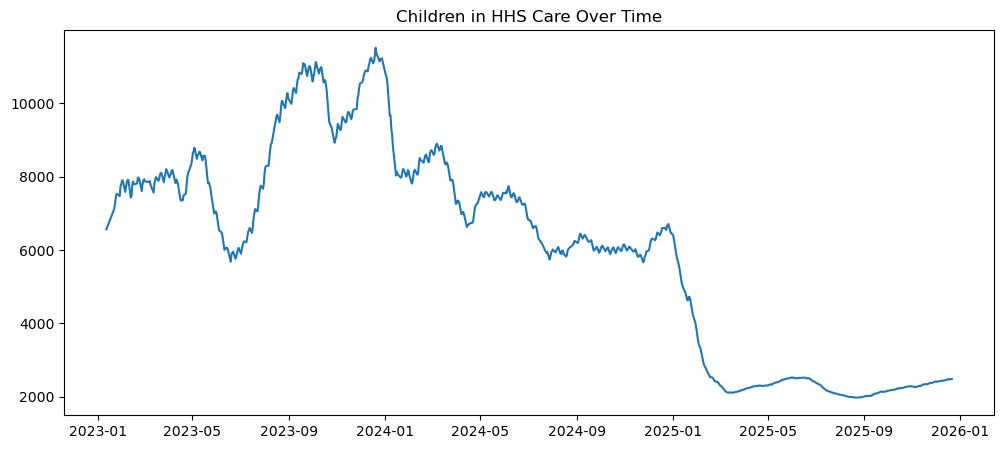

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df['Date'], df['Children in HHS Care'])
ax.set_title('Children in HHS Care Over Time')
plt.show()

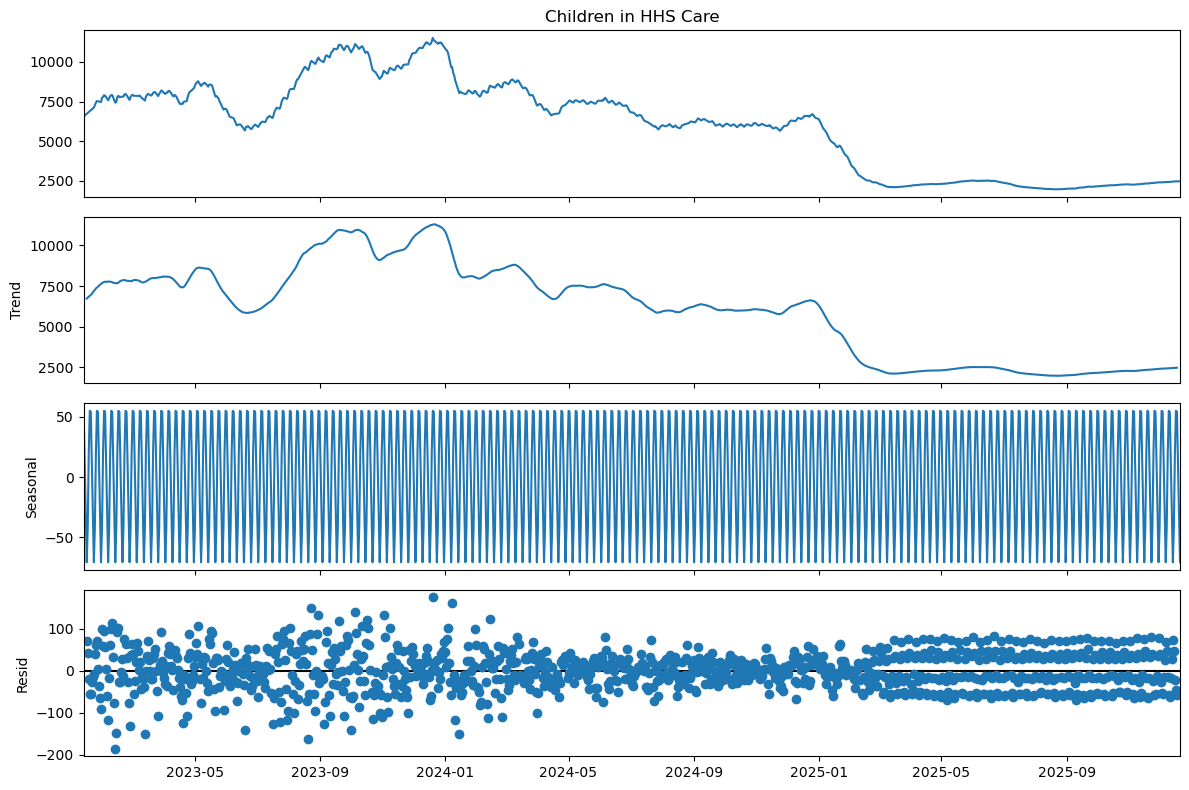

In [7]:
df = pd.read_csv(CLEANED_DATA_PATH, parse_dates=['Date'])
df = df.set_index('Date')

# Ensure continuity - reindex to a full daily range
full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')
df = df.reindex(full_range)
df.index.name = 'Date'

# Handle missing days - linear interpolation for numeric columns
numeric_cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care'
]
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

# Decompose the main series into trend, seasonality, residuals
decomposition = seasonal_decompose(df['Children in HHS Care'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

## 4. Feature Engineering

Build the predictive features:
- **Lag features** (t-1, t-7, t-14) — what the series looked like recently
- **Rolling mean/variance** (7-day, 14-day) — recent level and volatility
- **Net pressure** — inflow (transfers in) minus outflow (discharges), a
  proxy for capacity strain
- **Calendar effects** — day of week, month, weekend flag

In [8]:
target_col = 'Children in HHS Care'
discharge_col = 'Children discharged from HHS Care'
transfer_col = 'Children transferred out of CBP custody'

# -- Lag features (t-1, t-7, t-14) --
for lag in [1, 7, 14]:
    df[f'{target_col}_lag{lag}'] = df[target_col].shift(lag)
    df[f'{discharge_col}_lag{lag}'] = df[discharge_col].shift(lag)

# -- Rolling mean and variance (7-day and 14-day) --
for window in [7, 14]:
    df[f'{target_col}_roll_mean{window}'] = df[target_col].shift(1).rolling(window).mean()
    df[f'{target_col}_roll_var{window}'] = df[target_col].shift(1).rolling(window).var()

# -- Flow-based signal: net pressure indicator --
# Transfers in minus discharges out = net pressure on HHS care capacity
df['net_pressure'] = df[transfer_col] - df[discharge_col]
df['net_pressure_roll7'] = df['net_pressure'].shift(1).rolling(7).mean()

# -- Calendar effects --
df['day_of_week'] = df.index.dayofweek   # 0 = Monday, 6 = Sunday
df['month'] = df.index.month
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# -- Drop rows with NaNs created by lagging/rolling --
df_features = df.dropna()

print('Shape after feature engineering:', df_features.shape)
print(df_features.columns.tolist())
df_features.head()

Shape after feature engineering: (1061, 20)
['Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'Children in HHS Care_lag1', 'Children discharged from HHS Care_lag1', 'Children in HHS Care_lag7', 'Children discharged from HHS Care_lag7', 'Children in HHS Care_lag14', 'Children discharged from HHS Care_lag14', 'Children in HHS Care_roll_mean7', 'Children in HHS Care_roll_var7', 'Children in HHS Care_roll_mean14', 'Children in HHS Care_roll_var14', 'net_pressure', 'net_pressure_roll7', 'day_of_week', 'month', 'is_weekend']


,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Children in HHS Care_lag1,Children discharged from HHS Care_lag1,Children in HHS Care_lag7,Children discharged from HHS Care_lag7,Children in HHS Care_lag14,Children discharged from HHS Care_lag14,Children in HHS Care_roll_mean7,Children in HHS Care_roll_var7,Children in HHS Care_roll_mean14,Children in HHS Care_roll_var14,net_pressure,net_pressure_roll7,day_of_week,month,is_weekend
Date,,,,,,,,,,,,,,,,,,,,
2023-01-26,20.75,27.75,33.5,7521.5,210.75,7538.0,180.00,6955.2,289.7,6566.0,436.0,7200.771429,49097.579048,6966.785714,88279.535165,-177.25,-184.200000,3,1,0
2023-01-27,21.50,33.50,26.0,7505.0,241.50,7521.5,210.75,7010.8,268.8,6621.6,415.1,7281.671429,48555.549048,7035.035714,94576.910165,-215.50,-173.492857,4,1,0
2023-01-28,22.25,39.25,18.5,7488.5,272.25,7505.0,241.50,7066.4,247.9,6677.2,394.2,7352.271429,38824.515714,7098.135714,94130.356319,-253.75,-171.307143,5,1,1
2023-01-29,23.00,45.00,11.0,7472.0,303.00,7488.5,272.25,7122.0,227.0,6732.8,373.3,7412.571429,24055.035714,7156.085714,88605.938242,-292.00,-177.642857,6,1,1
2023-01-30,34.00,54.00,29.0,7743.0,196.00,7472.0,303.00,7280.0,181.0,6788.4,352.4,7462.571429,7655.035714,7208.885714,79498.344396,-167.00,-192.500000,0,1,0


## 5. Multi-Horizon Targets & Train/Test Split

Create shifted targets for 1-, 7-, and 14-day-ahead forecasts, define the
feature set (excluding raw target-adjacent columns to avoid leakage), and
hold out the most recent 60 days as a strict, time-ordered test set.

In [9]:
horizons = [1, 7, 14]

def build_horizon_targets(df, target_col, horizons):
    """Create shifted target columns for each forecast horizon."""
    for h in horizons:
        df[f'{target_col}_target_h{h}'] = df[target_col].shift(-h)
    return df

df_features = build_horizon_targets(df_features.copy(), target_col, horizons)
df_features = df_features.dropna()

print('Horizon targets created:', [f'{target_col}_target_h{h}' for h in horizons])

Horizon targets created: ['Children in HHS Care_target_h1', 'Children in HHS Care_target_h7', 'Children in HHS Care_target_h14']


In [10]:
# Feature columns: everything except the raw target-adjacent columns
# and the horizon targets themselves (avoids leaking the answer into X)
exclude_cols = [
    'Children apprehended and placed in CBP custody*',
    'Children in CBP custody',
    'Children transferred out of CBP custody',
    'Children in HHS Care',
    'Children discharged from HHS Care',
    'net_pressure',
] + [f'{target_col}_target_h{h}' for h in horizons]

feature_cols = [c for c in df_features.columns if c not in exclude_cols]

# -- Strict time-based split (no random sampling) --
# Hold out the most recent 60 days as the test set
test_size_days = 60
split_date = df_features.index[-test_size_days]

train_df_final = df_features[df_features.index < split_date]
test_df_final = df_features[df_features.index >= split_date]

print('Train range:', train_df_final.index.min(), 'to', train_df_final.index.max())
print('Test range:', test_df_final.index.min(), 'to', test_df_final.index.max())
print('Train shape:', train_df_final.shape, 'Test shape:', test_df_final.shape)

Train range: 2023-01-26 00:00:00 to 2025-10-08 00:00:00
Test range: 2025-10-09 00:00:00 to 2025-12-07 00:00:00
Train shape: (987, 23) Test shape: (60, 23)


## 6. Model Evaluation Framework

Define the metrics used to compare every model on equal footing:
**MAE** (average error size), **RMSE** (penalizes large errors more), and
**MAPE** (error as a percentage, easier to interpret across scales).

In [11]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, model_name, horizon):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape_val = mape(y_true, y_pred)
    return {'model': model_name, 'horizon': horizon, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape_val}

results = []

## 7. Baseline Models

Two simple benchmarks that any "real" model needs to beat:
- **Naive Persistence** — predicts tomorrow will look like today
- **Moving Average** — predicts the average of the last 7 days

In [12]:
def naive_forecast(test_data, target_col):
    """Walk-forward naive persistence: the forecast made at date t for
    date t+h is simply the actual value observed at date t. Unlike a
    single frozen value from the end of the training set, this updates
    every day as the test period rolls forward -- the same standard
    every other model in this notebook is held to."""
    return test_data[target_col].values

def moving_avg_forecast(test_data, target_col, window=7):
    """Walk-forward moving average: the forecast made at date t is the
    mean of the `window` days *before* t. We reuse the
    `{target_col}_roll_mean{window}` feature, which was built with
    .shift(1).rolling(window) in Section 4 -- so it already excludes
    date t itself and needs no extra shifting here."""
    col = f'{target_col}_roll_mean{window}'
    return test_data[col].values

for h in horizons:
    target = f'{target_col}_target_h{h}'
    y_test_h = test_df_final[target]

    naive_pred = naive_forecast(test_df_final, target_col)
    results.append(evaluate(y_test_h, naive_pred, 'Naive Persistence', h))

    ma_pred = moving_avg_forecast(test_df_final, target_col, window=7)
    results.append(evaluate(y_test_h, ma_pred, 'Moving Average', h))

## 8. Statistical Models

Classic time-series models that explicitly model trend and weekly
seasonality: **SARIMA** and **Exponential Smoothing**.

**Why this section looks different from a typical example:** to fairly
compare a 1-day, 7-day, and 14-day forecast, each prediction has to be made
by a model that only knows the past *relative to that specific day* — like
a weather forecaster who's only allowed to use data up through today to
predict next week, never peeking at next week's actual weather first.

The straightforward way to code SARIMA/Exponential Smoothing is to fit
once on the training set and forecast 60 days straight through the test
period. That's tempting, but it quietly breaks the horizon comparison: the
model's day-1 forecast ends up compared against the day-7 target, the
day-2 forecast against day-8, etc. Every horizon effectively gets graded
on the same fixed forecast, just measured against a different, shifted
answer key.

Instead, we use a **rolling-origin (walk-forward) backtest**: at every day
in the test period, look only at data up to that day, forecast forward,
and score the 1-, 7-, and 14-day-ahead predictions against the *actual*
values on those specific future dates. This mirrors exactly how the
Random Forest / Gradient Boosting models are evaluated, so the comparison
across all five models is apples-to-apples.

In [13]:
def rolling_origin_backtest(full_series, origin_dates, horizons, model_type,
                             order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                             seasonal_periods=7, min_history=30):
    """
    Walk-forward validation for a single-series statistical model.

    At each origin date, fit (SARIMA) or refit (Exponential Smoothing) using
    only data up to and including that date, then forecast far enough ahead
    to score every requested horizon against the *actual* value on that
    future date. This keeps every prediction honestly out-of-sample and
    correctly aligned, instead of reusing one long forecast for every
    horizon.

    SARIMA is fit once and then updated with `.append(..., refit=False)` as
    the origin rolls forward one day at a time -- this updates the filtered
    state cheaply without re-running the optimizer at every step.
    Exponential Smoothing (Holt-Winters) has no equivalent incremental
    update in statsmodels, so it is refit fresh at each origin.
    """
    records = []
    fitted_sarima = None

    for origin in origin_dates:
        loc = full_series.index.get_loc(origin)
        history = full_series.iloc[:loc + 1]
        if len(history) < min_history:
            continue

        # Only score horizons for which we actually have a future actual value
        usable_h = [h for h in horizons if loc + h < len(full_series)]
        if not usable_h:
            continue
        steps_needed = max(usable_h)

        if model_type == 'sarima':
            if fitted_sarima is None:
                fitted_sarima = SARIMAX(
                    history, order=order, seasonal_order=seasonal_order,
                    enforce_stationarity=False, enforce_invertibility=False
                ).fit(disp=False)
            else:
                fitted_sarima = fitted_sarima.append(history.iloc[[-1]], refit=False)
            forecast = fitted_sarima.forecast(steps=steps_needed)
        elif model_type == 'exp_smoothing':
            fit = ExponentialSmoothing(
                history, trend='add', seasonal='add',
                seasonal_periods=seasonal_periods
            ).fit()
            forecast = fit.forecast(steps=steps_needed)
        else:
            raise ValueError(f"Unknown model_type: {model_type}")

        for h in usable_h:
            records.append({
                'origin': origin,
                'horizon': h,
                'actual': full_series.iloc[loc + h],
                'pred': forecast.iloc[h - 1],
            })

    return pd.DataFrame(records)


# Full (train+test) target series, in order -- needed so a test-period
# origin can be scored against a future actual value that also lives in
# the test period.
full_target_series = df_features[target_col]

# Roll the origin forward from the last training day through the
# second-to-last test day (the final day can't be scored -- no future
# actuals exist beyond it).
origin_dates = df_features.loc[train_df_final.index[-1]:test_df_final.index[-1]].index[:-1]

sarima_backtest = rolling_origin_backtest(
    full_target_series, origin_dates, horizons, model_type='sarima'
)
for h in horizons:
    sub = sarima_backtest[sarima_backtest['horizon'] == h]
    results.append(evaluate(sub['actual'], sub['pred'], 'SARIMA', h))

es_backtest = rolling_origin_backtest(
    full_target_series, origin_dates, horizons, model_type='exp_smoothing'
)
for h in horizons:
    sub = es_backtest[es_backtest['horizon'] == h]
    results.append(evaluate(sub['actual'], sub['pred'], 'Exponential Smoothing', h))

## 9. Machine Learning Models

Two ensemble regressors trained on the engineered lag/rolling/calendar
features: **Random Forest** and **Gradient Boosting**.

In [14]:
X_train_ml = train_df_final[feature_cols]
X_test_ml = test_df_final[feature_cols]

for h in horizons:
    target = f'{target_col}_target_h{h}'
    y_tr = train_df_final[target]
    y_te = test_df_final[target]

    # -- Random Forest --
    rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
    rf_model.fit(X_train_ml, y_tr)
    rf_pred = rf_model.predict(X_test_ml)
    results.append(evaluate(y_te, rf_pred, 'Random Forest', h))

    # -- Gradient Boosting --
    gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42)
    gb_model.fit(X_train_ml, y_tr)
    gb_pred = gb_model.predict(X_test_ml)
    results.append(evaluate(y_te, gb_pred, 'Gradient Boosting', h))

## 10. Results Summary

Collect every model's metrics into one table, sorted by horizon and MAE,
then visualize MAE by model for each forecast horizon.

In [15]:
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(['horizon', 'MAE']).reset_index(drop=True)
results_df

,model,horizon,MAE,RMSE,MAPE
0,SARIMA,1,4.836868,6.156909,0.209874
1,Naive Persistence,1,6.133333,7.097633,0.265265
2,Random Forest,1,9.583872,12.543365,0.416565
3,Gradient Boosting,1,11.772650,15.607587,0.509193
4,Exponential Smoothing,1,18.084615,20.706702,0.786294
5,Moving Average,1,21.817460,23.640531,0.942024
6,SARIMA,7,21.066140,25.092240,0.911114
7,Random Forest,7,24.494792,27.947322,1.052249
8,Naive Persistence,7,29.363889,31.900014,1.254783
9,Gradient Boosting,7,41.468760,51.331643,1.752386


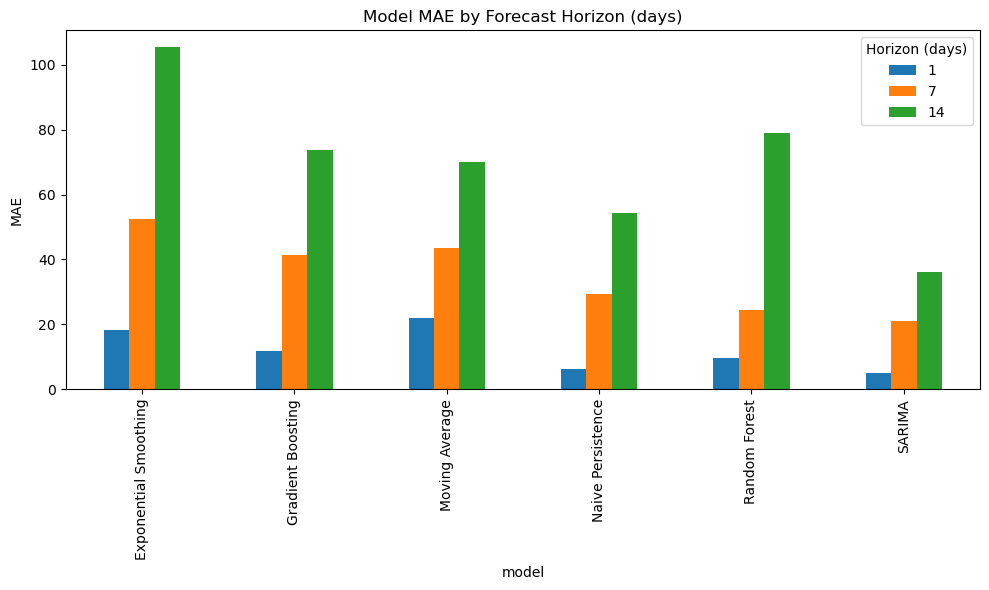

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))
pivot = results_df.pivot(index='model', columns='horizon', values='MAE')
pivot.plot(kind='bar', ax=ax)
ax.set_ylabel('MAE')
ax.set_title('Model MAE by Forecast Horizon (days)')
ax.legend(title='Horizon (days)')
plt.tight_layout()
plt.show()

## 11. Uncertainty Quantification

A point forecast alone doesn't tell a planner how much to trust it. This section adds a 90%
prediction interval to each model family:

- **SARIMA** already estimates uncertainty analytically -- we pull the confidence interval
  straight out of `get_forecast()` at each rolling-origin backtest step, instead of just the
  point mean used in Section 8.
- **Random Forest / Gradient Boosting** have no built-in interval, so we fit a second pair of
  Gradient Boosting models per horizon using **quantile loss** (5th and 95th percentile) to
  bracket the point forecast.

We report **interval coverage** -- the % of actual test values that fell inside the interval.
A well-calibrated 90% interval should cover close to 90% of actuals; much lower means the
model is overconfident (intervals too narrow), much higher means it's underconfident (too
wide to be useful).

In [17]:
def rolling_origin_backtest_with_ci(full_series, origin_dates, horizons,
                                     order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                                     min_history=30, alpha=0.10):
    """Same walk-forward SARIMA backtest as Section 8, but also captures the
    (1 - alpha) confidence interval for each forecasted step."""
    records = []
    fitted_sarima = None
    for origin in origin_dates:
        loc = full_series.index.get_loc(origin)
        history = full_series.iloc[:loc + 1]
        if len(history) < min_history:
            continue
        usable_h = [h for h in horizons if loc + h < len(full_series)]
        if not usable_h:
            continue
        steps_needed = max(usable_h)

        if fitted_sarima is None:
            fitted_sarima = SARIMAX(
                history, order=order, seasonal_order=seasonal_order,
                enforce_stationarity=False, enforce_invertibility=False
            ).fit(disp=False)
        else:
            fitted_sarima = fitted_sarima.append(history.iloc[[-1]], refit=False)

        fc = fitted_sarima.get_forecast(steps=steps_needed)
        mean_fc = fc.predicted_mean
        ci = fc.conf_int(alpha=alpha)

        for h in usable_h:
            records.append({
                'origin': origin,
                'horizon': h,
                'actual': full_series.iloc[loc + h],
                'pred': mean_fc.iloc[h - 1],
                'lower': ci.iloc[h - 1, 0],
                'upper': ci.iloc[h - 1, 1],
            })
    return pd.DataFrame(records)


sarima_ci_backtest = rolling_origin_backtest_with_ci(
    full_target_series, origin_dates, horizons, alpha=0.10  # 90% interval
)

interval_records = []

# --- SARIMA coverage ---
for h in horizons:
    sub = sarima_ci_backtest[sarima_ci_backtest['horizon'] == h]
    covered = (sub['actual'] >= sub['lower']) & (sub['actual'] <= sub['upper'])
    interval_records.append({
        'model': 'SARIMA', 'horizon': h, 'interval': '90%',
        'coverage_%': covered.mean() * 100 if len(sub) else np.nan,
        'avg_interval_width': (sub['upper'] - sub['lower']).mean() if len(sub) else np.nan,
    })

# --- Quantile Gradient Boosting for the ML family ---
for h in horizons:
    target = f'{target_col}_target_h{h}'
    y_tr = train_df_final[target]
    y_te = test_df_final[target]

    gb_lower = GradientBoostingRegressor(loss='quantile', alpha=0.05,
                                          n_estimators=200, max_depth=4,
                                          learning_rate=0.05, random_state=42)
    gb_upper = GradientBoostingRegressor(loss='quantile', alpha=0.95,
                                          n_estimators=200, max_depth=4,
                                          learning_rate=0.05, random_state=42)
    gb_lower.fit(X_train_ml, y_tr)
    gb_upper.fit(X_train_ml, y_tr)

    lower_pred = gb_lower.predict(X_test_ml)
    upper_pred = gb_upper.predict(X_test_ml)
    covered = (y_te.values >= lower_pred) & (y_te.values <= upper_pred)

    interval_records.append({
        'model': 'Gradient Boosting (quantile)', 'horizon': h, 'interval': '90%',
        'coverage_%': covered.mean() * 100,
        'avg_interval_width': (upper_pred - lower_pred).mean(),
    })

uncertainty_df = pd.DataFrame(interval_records).sort_values(['horizon', 'model']).reset_index(drop=True)
uncertainty_df

,model,horizon,interval,coverage_%,avg_interval_width
0,Gradient Boosting (quantile),1,90%,100.000000,3603.897160
1,SARIMA,1,90%,100.000000,162.541583
2,Gradient Boosting (quantile),7,90%,100.000000,1029.809590
3,SARIMA,7,90%,100.000000,841.592750
4,Gradient Boosting (quantile),14,90%,98.333333,469.833116
5,SARIMA,14,90%,100.000000,1759.228714


## 12. Operational KPIs

The metrics above (MAE / RMSE / MAPE) describe *model* quality. These five KPIs -- named in
the original project brief -- translate that into language a program planner cares about: how
much can they trust a forecast, how early will they be warned of a surge, and how stable is
that warning over time?

**The brief didn't specify exact formulas for these, so the definitions used below are a
documented first pass -- adjust `CAPACITY_THRESHOLD` and the definitions themselves once you
know the program's real bed/placement capacity and what "advance warning" needs to mean
operationally:**

- **Forecast Accuracy (%)** = 100 minus MAPE, per model/horizon.
- **Capacity Breach Probability** -- treating each backtest's residual spread as an
  approximate error distribution (Normal), the probability that the *true* value exceeds a
  capacity threshold given the point forecast. Threshold defaults to the 90th percentile of
  historical `Children in HHS Care`.
- **Surge Lead Time** -- the longest horizon (1, 7, or 14 days) at which a model's forecast
  leans toward flagging a breach (>=50% breach probability), i.e. how many days of advance
  warning that model can realistically offer.
- **Forecast Stability Index** -- split the 1-day-ahead backtest into calendar weeks, compute
  MAE per week, then report `1 - (std of weekly MAE / mean weekly MAE)`. Closer to 1 = the
  model performs consistently week to week; a low value means some weeks are much worse than
  others.
- **Model Robustness** -- ratio of 14-day-ahead MAE to 1-day-ahead MAE. Closer to 1 means the
  model barely degrades as the horizon lengthens; a large ratio means it should only be
  trusted for short-term calls.

In [18]:
from scipy.stats import norm

CAPACITY_THRESHOLD = df_features[target_col].quantile(0.90)
print(f"Capacity threshold (90th percentile of historical care load): {CAPACITY_THRESHOLD:.0f}")

# -- 1. Forecast Accuracy (%) --
results_df['forecast_accuracy_%'] = 100 - results_df['MAPE']

# -- 2. Capacity Breach Probability --
def breach_probability(preds, rmse, threshold):
    """P(actual > threshold) assuming Normal(pred, rmse) residuals, averaged over preds."""
    if rmse == 0 or np.isnan(rmse):
        return np.nan
    probs = 1 - norm.cdf((threshold - preds) / rmse)
    return probs.mean() * 100

breach_rows = []
for name, bt in [('SARIMA', sarima_backtest), ('Exponential Smoothing', es_backtest)]:
    for h in horizons:
        sub = bt[bt['horizon'] == h]
        rmse_h = results_df[(results_df['model'] == name) & (results_df['horizon'] == h)]['RMSE'].values[0]
        breach_rows.append({
            'model': name, 'horizon': h,
            'capacity_breach_probability_%': breach_probability(sub['pred'].values, rmse_h, CAPACITY_THRESHOLD)
        })

for h in horizons:
    target = f'{target_col}_target_h{h}'
    y_tr = train_df_final[target]

    rmse_rf = results_df[(results_df['model'] == 'Random Forest') & (results_df['horizon'] == h)]['RMSE'].values[0]
    rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42).fit(X_train_ml, y_tr)
    rf_pred = rf_model.predict(X_test_ml)
    breach_rows.append({'model': 'Random Forest', 'horizon': h,
                         'capacity_breach_probability_%': breach_probability(rf_pred, rmse_rf, CAPACITY_THRESHOLD)})

    rmse_gb = results_df[(results_df['model'] == 'Gradient Boosting') & (results_df['horizon'] == h)]['RMSE'].values[0]
    gb_model = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42).fit(X_train_ml, y_tr)
    gb_pred = gb_model.predict(X_test_ml)
    breach_rows.append({'model': 'Gradient Boosting', 'horizon': h,
                         'capacity_breach_probability_%': breach_probability(gb_pred, rmse_gb, CAPACITY_THRESHOLD)})

breach_df = pd.DataFrame(breach_rows).sort_values(['horizon', 'model']).reset_index(drop=True)

# -- 3. Surge Lead Time --
surge_lead_rows = []
for model_name in breach_df['model'].unique():
    hits = breach_df[(breach_df['model'] == model_name) &
                      (breach_df['capacity_breach_probability_%'] >= 50)]['horizon']
    surge_lead_rows.append({'model': model_name,
                             'surge_lead_time_days': int(hits.max()) if len(hits) else 0})
surge_lead_df = pd.DataFrame(surge_lead_rows)

# -- 4. Forecast Stability Index (weekly MAE consistency, 1-day-ahead backtests) --
stability_rows = []
for name, bt in [('SARIMA', sarima_backtest), ('Exponential Smoothing', es_backtest)]:
    sub = bt[bt['horizon'] == 1].copy()
    if sub.empty:
        continue
    sub['week'] = pd.to_datetime(sub['origin']).dt.isocalendar().week
    weekly_mae = sub.groupby('week').apply(lambda d: mean_absolute_error(d['actual'], d['pred']))
    stability = 1 - (weekly_mae.std() / weekly_mae.mean()) if weekly_mae.mean() else np.nan
    stability_rows.append({'model': name, 'forecast_stability_index': stability})
stability_df = pd.DataFrame(stability_rows)

# -- 5. Model Robustness (14-day MAE / 1-day MAE) --
robustness_rows = []
for model_name in results_df['model'].unique():
    mae_1 = results_df[(results_df['model'] == model_name) & (results_df['horizon'] == 1)]['MAE']
    mae_14 = results_df[(results_df['model'] == model_name) & (results_df['horizon'] == 14)]['MAE']
    if len(mae_1) and len(mae_14) and mae_1.values[0]:
        robustness_rows.append({'model': model_name, 'robustness_ratio_14v1': mae_14.values[0] / mae_1.values[0]})
robustness_df = pd.DataFrame(robustness_rows)

print("Forecast Accuracy & core metrics:")
display(results_df[['model', 'horizon', 'MAE', 'RMSE', 'MAPE', 'forecast_accuracy_%']])
print("\nCapacity Breach Probability:")
display(breach_df)
print("\nSurge Lead Time (days of advance warning, >=50% breach-probability threshold):")
display(surge_lead_df)
print("\nForecast Stability Index (closer to 1 = consistent week to week):")
display(stability_df)
print("\nModel Robustness -- 14-day MAE / 1-day MAE (closer to 1 = degrades less with horizon):")
display(robustness_df)

Capacity threshold (90th percentile of historical care load): 9828
Forecast Accuracy & core metrics:


C:\Users\asus\AppData\Local\Temp\ipykernel_2604\2490116542.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly_mae = sub.groupby('week').apply(lambda d: mean_absolute_error(d['actual'], d['pred']))
C:\Users\asus\AppData\Local\Temp\ipykernel_2604\2490116542.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weekly_mae = sub.groupby('week').apply(lambda d: mean_absolute_error(d['actual'], d['pred']))


,model,horizon,MAE,RMSE,MAPE,forecast_accuracy_%
0,SARIMA,1,4.836868,6.156909,0.209874,99.790126
1,Naive Persistence,1,6.133333,7.097633,0.265265,99.734735
2,Random Forest,1,9.583872,12.543365,0.416565,99.583435
3,Gradient Boosting,1,11.772650,15.607587,0.509193,99.490807
4,Exponential Smoothing,1,18.084615,20.706702,0.786294,99.213706
5,Moving Average,1,21.817460,23.640531,0.942024,99.057976
6,SARIMA,7,21.066140,25.092240,0.911114,99.088886
7,Random Forest,7,24.494792,27.947322,1.052249,98.947751
8,Naive Persistence,7,29.363889,31.900014,1.254783,98.745217
9,Gradient Boosting,7,41.468760,51.331643,1.752386,98.247614



Capacity Breach Probability:


,model,horizon,capacity_breach_probability_%
0,Exponential Smoothing,1,0.0
1,Gradient Boosting,1,0.0
2,Random Forest,1,0.0
3,SARIMA,1,0.0
4,Exponential Smoothing,7,0.0
5,Gradient Boosting,7,0.0
6,Random Forest,7,0.0
7,SARIMA,7,0.0
8,Exponential Smoothing,14,0.0
9,Gradient Boosting,14,0.0


...

,model,surge_lead_time_days
0,Exponential Smoothing,0
1,Gradient Boosting,0
2,Random Forest,0
3,SARIMA,0



Forecast Stability Index (closer to 1 = consistent week to week):


,model,forecast_stability_index
0,SARIMA,0.677231
1,Exponential Smoothing,0.832388



Model Robustness -- 14-day MAE / 1-day MAE (closer to 1 = degrades less with horizon):


,model,robustness_ratio_14v1
0,SARIMA,7.486242
1,Naive Persistence,8.865489
2,Random Forest,8.258857
3,Gradient Boosting,6.266657
4,Exponential Smoothing,5.829197
5,Moving Average,3.215660


## 13. Early-Warning Panel & Intake/Exit Imbalance

A single forward-looking snapshot for planners: using the most recent available data, forecast
the next 1/7/14 days with the best-performing model per horizon (lowest MAE from
`results_df`), flag any horizon whose forecast crosses `CAPACITY_THRESHOLD`, and report which
way the intake/exit balance (`net_pressure` = transfers into HHS care minus discharges) is
currently trending.

In [19]:
# Pick the best model per horizon (lowest MAE) to generate a live forward-looking panel
best_per_horizon = results_df.loc[results_df.groupby('horizon')['MAE'].idxmin()]

latest_row = df_features.iloc[[-1]]
X_latest = latest_row[feature_cols]

panel_rows = []
for _, row in best_per_horizon.iterrows():
    h, model_name = row['horizon'], row['model']
    target = f'{target_col}_target_h{h}'
    y_tr_full = df_features[target].dropna()
    X_tr_full = df_features.loc[y_tr_full.index, feature_cols]

    if model_name == 'Random Forest':
        m = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42).fit(X_tr_full, y_tr_full)
        pred = m.predict(X_latest)[0]
    elif model_name == 'Gradient Boosting':
        m = GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42).fit(X_tr_full, y_tr_full)
        pred = m.predict(X_latest)[0]
    elif model_name == 'Naive Persistence':
        pred = latest_row[target_col].values[0]
    elif model_name == 'Moving Average':
        pred = latest_row[f'{target_col}_roll_mean7'].values[0]
    else:
        # SARIMA / Exponential Smoothing: refit once on the full series for a live forecast
        full_series = df_features[target_col]
        if model_name == 'SARIMA':
            fit = SARIMAX(full_series, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7),
                          enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        else:
            fit = ExponentialSmoothing(full_series, trend='add', seasonal='add', seasonal_periods=7).fit()
        pred = fit.forecast(steps=h).iloc[-1]

    panel_rows.append({
        'horizon_days': h,
        'best_model': model_name,
        'forecast_care_load': round(pred),
        'capacity_threshold': round(CAPACITY_THRESHOLD),
        'capacity_stress_warning': bool(pred > CAPACITY_THRESHOLD),
    })

panel_df = pd.DataFrame(panel_rows)
print(f"Forecast as of {df_features.index[-1].date()}:")
display(panel_df)

# Intake/exit imbalance trend
# net_pressure = transfers into HHS care - discharges from HHS care
# positive -> more arriving than leaving (backlog building); negative -> draining down
recent_pressure = df_features['net_pressure'].tail(14)
trend = 'building up (intake > exits)' if recent_pressure.mean() > 0 else 'draining down (exits > intake)'
print(f"\nLast 14 days average net pressure: {recent_pressure.mean():.1f}")
print(f"Interpretation: care load is currently {trend}.")

Forecast as of 2025-12-07:


,horizon_days,best_model,forecast_care_load,capacity_threshold,capacity_stress_warning
0,1,SARIMA,2428,9828,False
1,7,SARIMA,2443,9828,False
2,14,SARIMA,2456,9828,False



Last 14 days average net pressure: 0.5
Interpretation: care load is currently building up (intake > exits).


### Notes for next iteration
- The best model per horizon is the top row of `results_df` for that horizon (lowest MAE).
- If ML models underperform the statistical baselines at short horizons, it usually means the engineered features aren't adding signal beyond recent lags -- worth checking feature importances (`rf_model.feature_importances_`).
- Update `RAW_DATA_PATH` at the top of the notebook if your CSV lives elsewhere.
- SARIMA/Exponential Smoothing are scored with a rolling-origin backtest (Section 8), so their MAE/RMSE at each horizon is directly comparable to the Random Forest/Gradient Boosting results -- no horizon misalignment.
- Naive Persistence and Moving Average (Section 7) now walk forward day-by-day with the test set instead of freezing on a single value from the end of training -- they should look like real "beat this" baselines now, not a bug-inflated worst case.
- Sections 11-13 are new: prediction intervals with coverage checks, five operational KPIs (accuracy, breach probability, surge lead time, stability, robustness), and a live early-warning panel with the current intake/exit imbalance. The KPI formulas are a first-pass definition since the original brief didn't specify exact math -- revisit `CAPACITY_THRESHOLD` and the breach/lead-time logic once real program capacity numbers are available.